PROJECT 1 : predicting house prices usng linear regression

1.  OBJECTIVE :  The goal of this project is to build predictive model using linear regression to estimate house prices based on various features such as area , location and number of rooms

2. Dateset
includes Area ,Bedrooms ,
Location
Price - our target Variable

In [6]:
#import and load

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('/content/Housing (1).csv', sep=',')
print(df.shape)
df.head()

(545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [7]:
#explore data
print(df.isnull().sum())
df.describe()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [8]:
# encode yes/no columns
le = LabelEncoder()
cols = ['mainroad','guestroom','basement','hotwaterheating',
        'airconditioning','prefarea','furnishingstatus']
for col in cols:
    df[col] = le.fit_transform(df[col])

In [12]:
# Feature selction
X = df.drop('price', axis=1)
y = df['price']
print(X)
print(y)

     area  bedrooms  bathrooms  ...  parking  prefarea  furnishingstatus
0    7420         4          2  ...        2         1                 0
1    8960         4          4  ...        3         0                 0
2    9960         3          2  ...        2         1                 1
3    7500         4          2  ...        3         1                 0
4    7420         4          1  ...        2         0                 0
..    ...       ...        ...  ...      ...       ...               ...
540  3000         2          1  ...        2         0                 2
541  2400         3          1  ...        0         0                 1
542  3620         2          1  ...        0         0                 2
543  2910         3          1  ...        0         0                 0
544  3850         3          1  ...        0         0                 2

[545 rows x 12 columns]
0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540

In [16]:
#split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(X)

print(y)

     area  bedrooms  bathrooms  ...  parking  prefarea  furnishingstatus
0    7420         4          2  ...        2         1                 0
1    8960         4          4  ...        3         0                 0
2    9960         3          2  ...        2         1                 1
3    7500         4          2  ...        3         1                 0
4    7420         4          1  ...        2         0                 0
..    ...       ...        ...  ...      ...       ...               ...
540  3000         2          1  ...        2         0                 2
541  2400         3          1  ...        0         0                 1
542  3620         2          1  ...        0         0                 2
543  2910         3          1  ...        0         0                 0
544  3850         3          1  ...        0         0                 2

[545 rows x 12 columns]
0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540

In [17]:
#train data model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [18]:
#evaluate the model
predictions = model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print("R2 Score:", r2)
print("MSE:", mse)

R2 Score: 0.6494754192267803
MSE: 1771751116594.0352


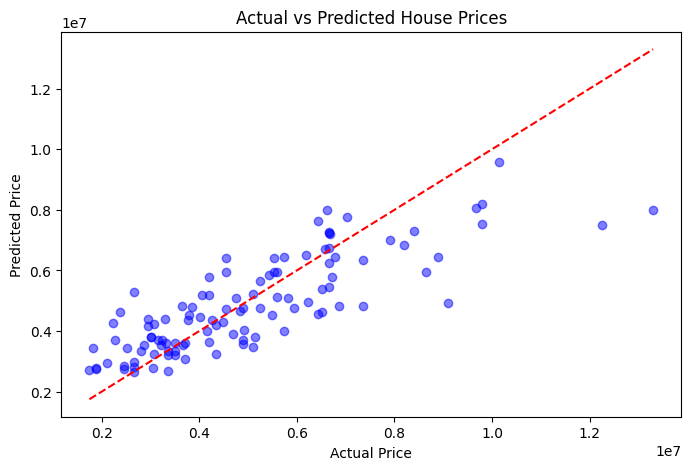

In [19]:
#visualize predicated vs actual

plt.figure(figsize=(8,5))
plt.scatter(y_test, predictions, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.show()

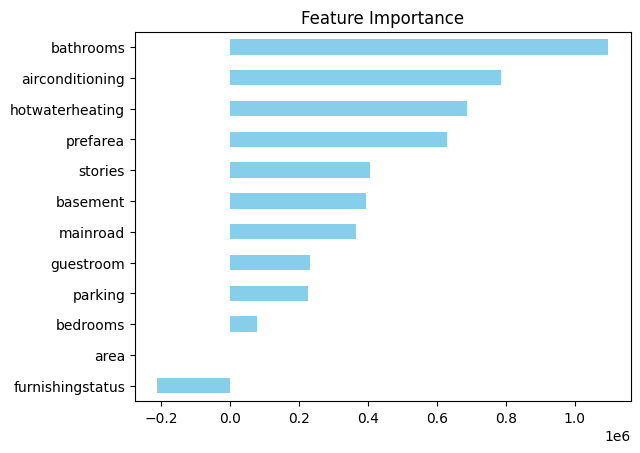

In [20]:
#Feature importance
importance = pd.Series(model.coef_, index=X.columns)
importance.sort_values().plot(kind='barh', color='skyblue')
plt.title('Feature Importance')
plt.show()

#House Price Prediction Observations

- Dataset: Housing prices with features like area, bedrooms, bathrooms
- Model used: Linear Regression
- R2 Score: 0.649

This means the model explains 64.9% of the variation in house prices.
Roughly 65 out of 100 predictions are in the correct range.

Key factors affecting house price:
- Area (size of house) had the highest impact
- Number of bathrooms also significantly affects price
- Airconditioning and preferred area add to price

Limitations:
- 35% of price variation is not explained by this model
- A more complex model like Random Forest could improve accuracy
